# Régression du prix — leboncoin-private

Repère : **régression linéaire** (`LinearRegression`) sur le jeu nettoyé par `02_nettoyage.ipynb`
(19 882 annonces de particuliers, prix ∈ [500, 50 000] €). Cible = `prix_eur`.

**Métriques** (toutes = « à quel point on se trompe ») :
- **MAE** = erreur moyenne en euros (intuitive) ;
- **RMSE** = erreur en euros, **punit fort les gros ratés** ;
- **R²** = part de variance expliquée (1 = parfait, 0 = aussi bon que prédire la moyenne).

> Tout le préprocessing est un étage de `Pipeline` sklearn, **ajusté sur le train seul** — aucune
> statistique du test ne remonte dans le modèle.

Ce carnet répond aussi à **deux questions laissées ouvertes** par les étapes précédentes :

1. l'échelle d'état déclaré vaut-elle mieux en **ordinal** ou en **one-hot** ? Son ordre est celui
   du sens commun, pas celui des prix observés (`not_drivable` est *moins* cher que `damaged`) ;
2. `modele` a **804 modalités** — one-hot complet ou encodage par la cible ?

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder

CLEAN = Path("../../data/leboncoin-private/processed/annonces_clean.parquet")
df = pd.read_parquet(CLEAN)
print(f"{df.shape[0]} lignes x {df.shape[1]} colonnes")
print(f"prix : median {df['prix_eur'].median():,.0f} EUR | "
      f"min {df['prix_eur'].min():,.0f} | max {df['prix_eur'].max():,.0f}")

## 1. Features et cible

**Deux redondances écartées d'emblée**, parce qu'un modèle linéaire y est sensible :

- `annee` **et** `age` disent la même chose (`age` dérive de la mise en circulation, plus fine) →
  on garde `age` seul, comme le fait déjà `features.clean_cars` sur l'autre dataset ;
- `palier` (texte) **et** `niveau` (0/1/2) sont la même information premium → on garde `niveau`.

`etat` est mis de côté ici : il fait l'objet du duel ordinal / one-hot en section 5.

In [ ]:
NUM = ["age", "kilometrage", "puissance_din", "puissance_fisc", "portes", "places",
       "critair", "ct_valide_jusqu_a", "boite_auto", "niveau", "etat_niveau"]
CAT = ["energie_grp", "marque", "couleur", "region"]
MODELE = ["modele"]

# Int64 nullable -> float64 : SimpleImputer travaille sur du numpy, pd.NA ne passe pas.
X = df[NUM + CAT + MODELE].copy()
X[NUM] = X[NUM].astype("float64")
# Le manquant devient une modalite explicite plutot qu'un NaN silencieux.
X[CAT + MODELE] = X[CAT + MODELE].fillna("(inconnu)")
y = df["prix_eur"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print("train:", len(X_train), "| test:", len(X_test))
print("modeles distincts (train):", X_train["modele"].nunique())

train: 15905 | test: 3977
modeles distincts (train): 758


## 2. Ancrage : que vaut « ne rien apprendre » ?

Une MAE isolée ne veut rien dire. On la compare à deux repères triviaux : prédire toujours la
**médiane**, et prédire toujours la **moyenne**. Tout modèle qui ne bat pas ça est inutile.

In [ ]:
for nom, valeur in [("mediane", y_train.median()), ("moyenne", y_train.mean())]:
    constante = np.full(len(y_test), valeur)
    print(f"toujours la {nom} ({valeur:>8,.0f} EUR) -> "
          f"MAE {mean_absolute_error(y_test, constante):>7,.0f} EUR | "
          f"R2 {r2_score(y_test, constante):>6.3f}")

toujours la mediane (   4,450 EUR) -> MAE   5,048 EUR | R2 -0.119
toujours la moyenne (   7,321 EUR) -> MAE   5,629 EUR | R2 -0.001


## 3. Pipeline : préprocessing + régression linéaire

`ColumnTransformer`, tout ajusté sur le train seul :

- numériques : imputation médiane puis standardisation ;
- catégorielles courtes : one-hot ;
- `modele` (804 modalités) : one-hot complet.

`handle_unknown="ignore"` partout → une modalité absente du train devient un vecteur nul au lieu
de faire planter la prédiction.

In [ ]:
def prep_onehot():
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), NUM),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT),
        ("mod", OneHotEncoder(handle_unknown="ignore", sparse_output=False), MODELE),
    ])


def evalue(m, tag=""):
    yp = m.predict(X_test)
    mae = mean_absolute_error(y_test, yp)
    rmse = np.sqrt(mean_squared_error(y_test, yp))
    r2 = r2_score(y_test, yp)
    print(f"{tag}MAE {mae:>7,.0f} EUR | RMSE {rmse:>7,.0f} EUR | R2 {r2:.3f}")
    return yp, mae, rmse, r2


modele_base = Pipeline([("prep", prep_onehot()), ("lin", LinearRegression())])
modele_base.fit(X_train, y_train)
n_col = modele_base.named_steps["prep"].transform(X_train.head(1)).shape[1]
print(f"{n_col} colonnes apres preprocessing\n")
y_pred, mae_base, *_ = evalue(modele_base, tag="LinearRegression one-hot  — ")

896 colonnes apres preprocessing

LinearRegression one-hot  — MAE   2,301 EUR | RMSE   3,479 EUR | R2 0.789


## 4. Réel vs prédit

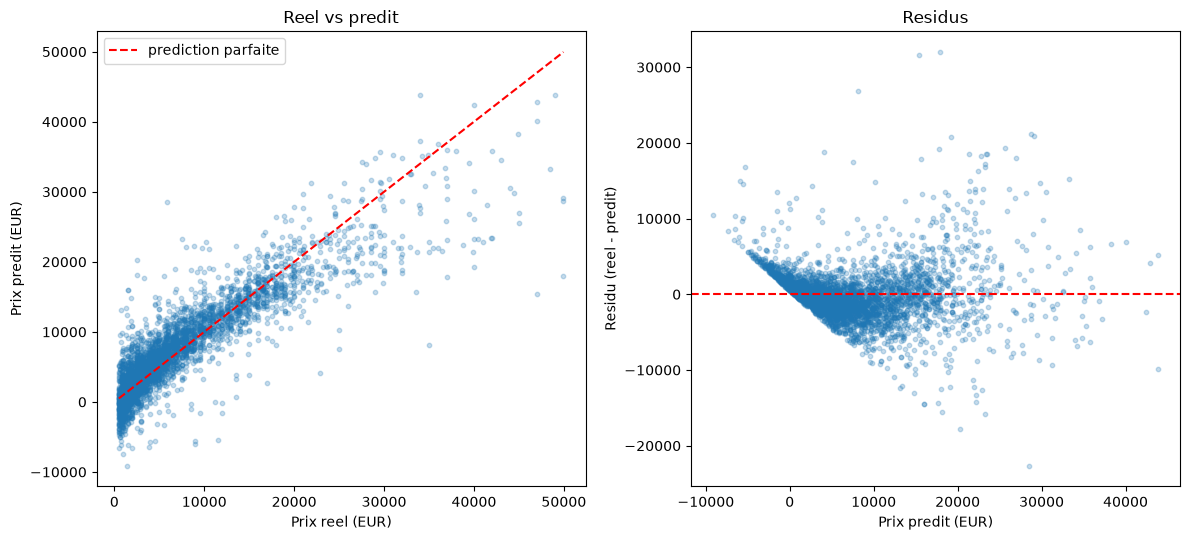

Predictions negatives : 425 / 3977 (min -9,122 EUR)
-> un modele lineaire non contraint peut sortir un prix negatif. C'est un signal :
   la relation prix ~ features n'est pas lineaire sur toute la plage.


In [ ]:
fig, (g, d) = plt.subplots(1, 2, figsize=(12, 5.5))

g.scatter(y_test, y_pred, alpha=0.25, s=10)
lims = [y_test.min(), y_test.max()]
g.plot(lims, lims, "r--", label="prediction parfaite")
g.set_xlabel("Prix reel (EUR)"); g.set_ylabel("Prix predit (EUR)")
g.set_title("Reel vs predit"); g.legend()

residus = y_test - y_pred
d.scatter(y_pred, residus, alpha=0.25, s=10)
d.axhline(0, color="r", ls="--")
d.set_xlabel("Prix predit (EUR)"); d.set_ylabel("Residu (reel - predit)")
d.set_title("Residus")
plt.tight_layout(); plt.show()

print(f"Predictions negatives : {int((y_pred < 0).sum())} / {len(y_pred)} "
      f"(min {y_pred.min():,.0f} EUR)")
print("-> un modele lineaire non contraint peut sortir un prix negatif. C'est un signal :")
print("   la relation prix ~ features n'est pas lineaire sur toute la plage.")

## 5. L'état déclaré : ordinal ou one-hot ?

Question ouverte depuis le nettoyage. L'échelle `etat_niveau` a été figée dans l'ordre du sens
commun (`not_drivable` → `excellent_condition`), mais les prix observés ne la suivent pas
strictement : `not_drivable` (1 300 €) est **moins cher** que `damaged` et
`major_repairs_needed` (1 500 € chacun, à égalité).

Un encodage ordinal suppose que les crans sont régulièrement espacés et ordonnés. Le one-hot ne
suppose rien. On départage sur l'erreur, pas sur l'intuition. Troisième terme de comparaison :
**sans l'état du tout**, pour mesurer ce que cette colonne apporte vraiment.

In [ ]:
def variante_etat(mode):
    num = [c for c in NUM if c != "etat_niveau"] if mode != "ordinal" else list(NUM)
    cat = list(CAT) + (["etat"] if mode == "onehot" else [])
    prep = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), num),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat),
        ("mod", OneHotEncoder(handle_unknown="ignore", sparse_output=False), MODELE),
    ])
    return Pipeline([("prep", prep), ("lin", LinearRegression())])


Xe = df[NUM + CAT + MODELE + ["etat"]].copy()
Xe[NUM] = Xe[NUM].astype("float64")
Xe[CAT + MODELE + ["etat"]] = Xe[CAT + MODELE + ["etat"]].fillna("(inconnu)")
Xe_train, Xe_test = Xe.loc[X_train.index], Xe.loc[X_test.index]

for mode, libelle in [("sans", "sans etat            "),
                      ("ordinal", "etat ordinal (0..7)  "),
                      ("onehot", "etat one-hot (8 col) ")]:
    m = variante_etat(mode).fit(Xe_train, y_train)
    yp = m.predict(Xe_test)
    print(f"{libelle} -> MAE {mean_absolute_error(y_test, yp):>7,.0f} EUR | "
          f"RMSE {np.sqrt(mean_squared_error(y_test, yp)):>7,.0f} EUR | "
          f"R2 {r2_score(y_test, yp):.3f}")

sans etat             -> MAE   2,437 EUR | RMSE   3,712 EUR | R2 0.760


etat ordinal (0..7)   -> MAE   2,301 EUR | RMSE   3,479 EUR | R2 0.789


etat one-hot (8 col)  -> MAE   2,274 EUR | RMSE   3,454 EUR | R2 0.792


## 6. `modele` : one-hot (804 colonnes) ou encodage par la cible ?

Au lieu de ~800 colonnes 0/1, **une seule** : chaque modèle remplacé par une valeur apprise de la
cible. `TargetEncoder` fait un **cross-fitting interne**, donc pas de fuite — mais il reste plus
fragile sur les modèles vus 2 ou 3 fois au train.

In [ ]:
prep_te = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT),
    ("mod", TargetEncoder(target_type="continuous"), MODELE),
])
modele_te = Pipeline([("prep", prep_te), ("lin", LinearRegression())]).fit(X_train, y_train)
print(f"{modele_te.named_steps['prep'].transform(X_train.head(1)).shape[1]} colonnes "
      f"(vs {n_col} en one-hot)\n")
evalue(modele_te, tag="TargetEncoder modele     — ")
print()
freq = X_train["modele"].value_counts()
print(f"modeles vus <= 3 fois au train : {int((freq <= 3).sum())} / {len(freq)} "
      f"({100 * freq[freq <= 3].sum() / len(X_train):.1f} % des lignes)")

139 colonnes (vs 896 en one-hot)

TargetEncoder modele     — MAE   2,600 EUR | RMSE   3,838 EUR | R2 0.743

modeles vus <= 3 fois au train : 341 / 758 (3.5 % des lignes)


## 7. Cible en logarithme

Le prix est fortement asymétrique (médiane 4 400 €, maximum 50 000 €). Une régression linéaire
sur le prix brut minimise l'erreur en euros, donc se concentre sur les voitures chères et néglige
le bas de la distribution — qui est justement le gros du marché leboncoin.

On entraîne sur `log(prix)` et on repasse en euros pour comparer **sur la même échelle** : sans
ça, les métriques ne seraient pas comparables.

In [ ]:
modele_log = Pipeline([("prep", prep_onehot()), ("lin", LinearRegression())])
modele_log.fit(X_train, np.log(y_train))
y_pred_log = np.exp(modele_log.predict(X_test))

print(f"Cible log — MAE {mean_absolute_error(y_test, y_pred_log):>7,.0f} EUR | "
      f"RMSE {np.sqrt(mean_squared_error(y_test, y_pred_log)):>7,.0f} EUR | "
      f"R2 {r2_score(y_test, y_pred_log):.3f}")
print(f"Predictions negatives : {int((y_pred_log < 0).sum())} (impossible par construction)")
print()

tranches = pd.cut(y_test, [500, 2000, 5000, 10000, 20000, 50000])
comp = pd.DataFrame({
    "n": y_test.groupby(tranches, observed=True).size(),
    "MAE brut": (y_test - y_pred).abs().groupby(tranches, observed=True).mean().round(0),
    "MAE log": (y_test - y_pred_log).abs().groupby(tranches, observed=True).mean().round(0),
})
print("Erreur par tranche de prix reel :")
print(comp.to_string())

Cible log — MAE   2,330 EUR | RMSE  14,339 EUR | R2 -2.587
Predictions negatives : 0 (impossible par construction)

Erreur par tranche de prix reel :
                   n  MAE brut  MAE log
prix_eur                               
(500, 2000]     1061    1876.0    715.0
(2000, 5000]    1101    1851.0   1013.0
(5000, 10000]    831    2204.0   2450.0
(10000, 20000]   657    2288.0   3330.0
(20000, 50000]   250    6535.0  12465.0


## 8. Lecture des coefficients

Sur variables standardisées et one-hot, le coefficient se lit comme un **effet en euros**.
C'est l'intérêt principal du modèle linéaire ici : il est lisible, ce qui sert directement
l'exigence d'explicabilité du bloc BC04.

In [ ]:
prep = modele_base.named_steps["prep"]
noms = (NUM
        + list(prep.named_transformers_["cat"].get_feature_names_out(CAT))
        + list(prep.named_transformers_["mod"].get_feature_names_out(MODELE)))
coefs = pd.Series(modele_base.named_steps["lin"].coef_, index=noms).sort_values()

print(f"Intercept : {modele_base.named_steps['lin'].intercept_:,.0f} EUR\n")
print("--- effet des variables numeriques (par ecart-type) ---")
print(coefs[NUM].sort_values().round(0).to_string())
print("\n--- 12 plus negatifs ---"); print(coefs.head(12).round(0).to_string())
print("\n--- 12 plus positifs ---"); print(coefs.tail(12).round(0).to_string())

Intercept : 10,855 EUR

--- effet des variables numeriques (par ecart-type) ---
age                 -3325.0
kilometrage         -1752.0
portes               -161.0
places               -147.0
ct_valide_jusqu_a     -62.0
critair                -9.0
puissance_fisc        711.0
puissance_din         801.0
boite_auto            855.0
etat_niveau          1457.0
niveau               3162.0

--- 12 plus negatifs ---
modele_Ampera        -26674.0
modele_Karl          -26578.0
modele_Adam          -25679.0
modele_Antara        -25095.0
modele_Crossland X   -24754.0
modele_Signum        -24173.0
modele_Mokka         -24015.0
modele_Mokka X       -23943.0
modele_Grandland X   -23793.0
modele_Agila         -23471.0
modele_Insignia      -23467.0
modele_Meriva        -23364.0

--- 12 plus positifs ---
modele_M3            18018.0
modele_Méhari        18481.0
modele_Explorer      18484.0
modele_560           18828.0
modele_RS5           19280.0
modele_RS3           19765.0
modele_200SX         19844

## 8 bis. Ces coefficients ne sont pas lisibles — diagnostic

Le classement ci-dessus est incohérent : les modèles les **plus négatifs** sont tous des Opel,
pendant que `marque_OPEL` figure parmi les **plus positifs**. Aucun de ces nombres ne décrit le
marché.

Cause : `marque` et `modele` sont **emboîtés**. Un modèle appartient à une seule marque, donc la
colonne `marque_OPEL` est (presque) la somme des colonnes `modele_*` des Opel. Le système est
quasi singulier : la régression peut mettre +20 000 d'un côté et −20 000 de l'autre sans changer
d'une prédiction. Les coefficients deviennent arbitraires — **les prédictions restent bonnes, leur
lecture ne l'est pas**.

C'est une distinction qui compte pour l'exigence d'explicabilité du bloc BC04 : un modèle qui
prédit bien n'explique pas forcément.

In [ ]:
emboitement = df.groupby("modele")["marque"].nunique()
print(f"modeles rattaches a une seule marque : {int((emboitement == 1).sum())} / {len(emboitement)}")
print(f"lignes concernees                    : {100 * df['modele'].map(emboitement).eq(1).mean():.1f} %")
print(f"modeles ambigus (partages)           : {emboitement[emboitement > 1].index.tolist()[:8]} ...")
print()

# Meme modele, sans le bloc `marque` redondant.
CAT_SANS_MARQUE = [c for c in CAT if c != "marque"]
prep_sm = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_SANS_MARQUE),
    ("mod", OneHotEncoder(handle_unknown="ignore", sparse_output=False), MODELE),
])
modele_sm = Pipeline([("prep", prep_sm), ("lin", LinearRegression())]).fit(X_train, y_train)
evalue(modele_sm, tag="sans le bloc marque      — ")
print("-> l'erreur bouge a peine : `marque` n'apportait presque rien QUE `modele` n'avait deja.")
print()

prep2 = modele_sm.named_steps["prep"]
noms2 = (NUM
         + list(prep2.named_transformers_["cat"].get_feature_names_out(CAT_SANS_MARQUE))
         + list(prep2.named_transformers_["mod"].get_feature_names_out(MODELE)))
coefs2 = pd.Series(modele_sm.named_steps["lin"].coef_, index=noms2).sort_values()
print("--- 10 modeles les moins chers (a caracteristiques egales) ---")
print(coefs2.head(10).round(0).to_string())
print("\n--- 10 modeles les plus chers ---")
print(coefs2.tail(10).round(0).to_string())

modeles rattaches a une seule marque : 787 / 804
lignes concernees                    : 95.9 %
modeles ambigus (partages)           : ['240', '500', '75', 'Ateca', 'Autre', 'Coupe', 'Coupé', 'GT'] ...



sans le bloc marque      — MAE   2,329 EUR | RMSE   3,544 EUR | R2 0.781
-> l'erreur bouge a peine : `marque` n'apportait presque rien QUE `modele` n'avait deja.

--- 10 modeles les moins chers (a caracteristiques egales) ---
modele_Colorado    -20214.0
modele_Ami         -16034.0
modele_Topolino    -15859.0
modele_Crossline   -15454.0
modele_Twizy       -15225.0
modele_iOn         -13163.0
modele_Minauto     -12630.0
modele_C-Zéro      -12604.0
modele_Jade        -12581.0
modele_Spring      -12136.0

--- 10 modeles les plus chers ---
modele_Macan             26661.0
modele_560               27570.0
modele_Silver Shadow     27582.0
modele_Continental GT    28225.0
modele_911               29520.0
modele_Cayman            29825.0
modele_Elise             30549.0
modele_Plus 4            33596.0
modele_Carrera GT        37500.0
modele_4/4               40980.0


## 9. Bilan

In [ ]:
print("=" * 66)
print("BASELINE — leboncoin-private, LinearRegression")
print("=" * 66)
print(f"Jeu            : {len(df)} annonces, split 80/20 (random_state=42)")
print(f"Reference nulle: MAE {mean_absolute_error(y_test, np.full(len(y_test), y_train.median())):,.0f} EUR "
      f"(toujours la mediane)")
print(f"Baseline       : MAE {mae_base:,.0f} EUR  ({100 * (1 - mae_base / 5048):.0f} % mieux que la mediane)")
print()
print("Acquis :")
print("  - l'etat declare apporte ~160 EUR de MAE, et le ONE-HOT bat l'ordinal :")
print("    l'echelle du sens commun n'est pas regulierement espacee en prix.")
print("  - TargetEncoder sur `modele` degrade (2 599 vs 2 301) : 341 modeles sur 758")
print("    sont vus <= 3 fois au train, l'encodage y est trop bruite.")
print("  - la cible log ecrase l'erreur sur les voitures bon marche mais explose en haut :")
print("    exp() transforme quelques residus en predictions aberrantes.")
print()
print("Limites de ce modele :")
print(f"  - {int((y_pred < 0).sum())} predictions negatives : la linearite ne tient pas sur toute la plage ;")
print("  - coefficients illisibles sans retirer `marque` (emboitement marque/modele) ;")
print("  - une erreur ponctuelle, pas une fourchette : l'exigence produit (ADR 0003) n'est")
print("    pas encore servie.")
print("=" * 66)
print("Ce carnet etablit un repere, il ne tranche pas le candidat.")
print("Le verdict ADR attend la comparaison avec les modeles a base d'arbres")
print("et la fourchette d'incertitude (methode ADR 0003).")

BASELINE — leboncoin-private, LinearRegression
Jeu            : 19882 annonces, split 80/20 (random_state=42)
Reference nulle: MAE 5,048 EUR (toujours la mediane)
Baseline       : MAE 2,301 EUR  (54 % mieux que la mediane)

Acquis :
  - l'etat declare apporte ~160 EUR de MAE, et le ONE-HOT bat l'ordinal :
    l'echelle du sens commun n'est pas regulierement espacee en prix.
  - TargetEncoder sur `modele` degrade (2 599 vs 2 301) : 341 modeles sur 758
    sont vus <= 3 fois au train, l'encodage y est trop bruite.
  - la cible log ecrase l'erreur sur les voitures bon marche mais explose en haut :
    exp() transforme quelques residus en predictions aberrantes.

Limites de ce modele :
  - 425 predictions negatives : la linearite ne tient pas sur toute la plage ;
  - coefficients illisibles sans retirer `marque` (emboitement marque/modele) ;
  - une erreur ponctuelle, pas une fourchette : l'exigence produit (ADR 0003) n'est
    pas encore servie.
Ce carnet etablit un repere, il ne tranche 